# Job Application EDA
This notebook performs an exploratory data analysis on job application data.
The applications are in Data field in period of January - March 2026.

### A. Data extract and cleaning

In [178]:
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datetime import datetime

# Load the dataset.
df = pd.read_excel("job_applications.xlsx", header=1)
df = df.iloc[:, 1:]  # Drop the first empty column

# Anonymize company names and drop 'link' column if it exists
unique_cos = df["company"].unique()
mapping = {name: f"Company {i+1}" for i, name in enumerate(unique_cos)}
df["company"] = df["company"].map(mapping)
if "link" in df.columns:
    df = df.drop(columns=["link"])


# Title cleaning logic.
def clean_title(title):
    if pd.isna(title):
        return title
    # Remove everything inside parentheses.
    title = re.sub(r"\(.*?\)", "", title)
    # Split by common delimiters and take the first part.
    for delimiter in [" - ", "-", "|", ","]:
        title = title.split(delimiter)[0]
    return title.strip()


df["title"] = df["title"].apply(clean_title)

# Date conversion.
date_cols = [
    "apply_done",
    "apply_response",
    "screening_done",
    "screening_response",
    "initial_technical_done",
    "initial_technical_response",
    "final_technical_done",
    "final_technical_response",
    "behavior_done",
    "behavior_response",
    "offer_done",
    "offer_response",
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print("Dataset Sample:")
df.head()

Dataset Sample:


,company,title,apply_status,apply_done,apply_response,screening_status,screening_done,screening_response,initial_technical_status,initial_technical_done,...,home_work_status,final_technical_status,final_technical_done,final_technical_response,behavior_status,behavior_done,behavior_response,offer_status,offer_done,offer_response
0,Company 1,Data Engineer,INVITATION,NaT,NaT,PASS,2026-01-30,2026-02-09,PASS,2026-02-09,...,NO,PASS,2026-02-09,2026-02-09,FAILED,2026-02-09,2026-02-19,NaN,NaT,NaT
1,Company 1,Senior Data Engineer,INVITATION,NaT,NaT,FAILED,2026-02-19,2026-02-23,NaN,NaT,...,NaN,NaN,NaT,NaT,NaN,NaT,NaT,NaN,NaT,NaT
2,Company 1,Senior Data Engineer,INVITATION,NaT,NaT,PASS,2026-02-23,2026-02-23,WAIT,2026-02-25,...,NaN,NaN,NaT,NaT,NaN,NaT,NaT,NaN,NaT,NaT
3,Company 2,Data Engineer,WAIT,2026-01-17,NaT,NaN,NaT,NaT,NaN,NaT,...,NaN,NaN,NaT,NaT,NaN,NaT,NaT,NaN,NaT,NaT
4,Company 3,Lead AI Engineer,WAIT,2026-01-18,NaT,NaN,NaT,NaT,NaN,NaT,...,NaN,NaN,NaT,NaT,NaN,NaT,NaT,NaN,NaT,NaT


### 1. Job Application Funnel

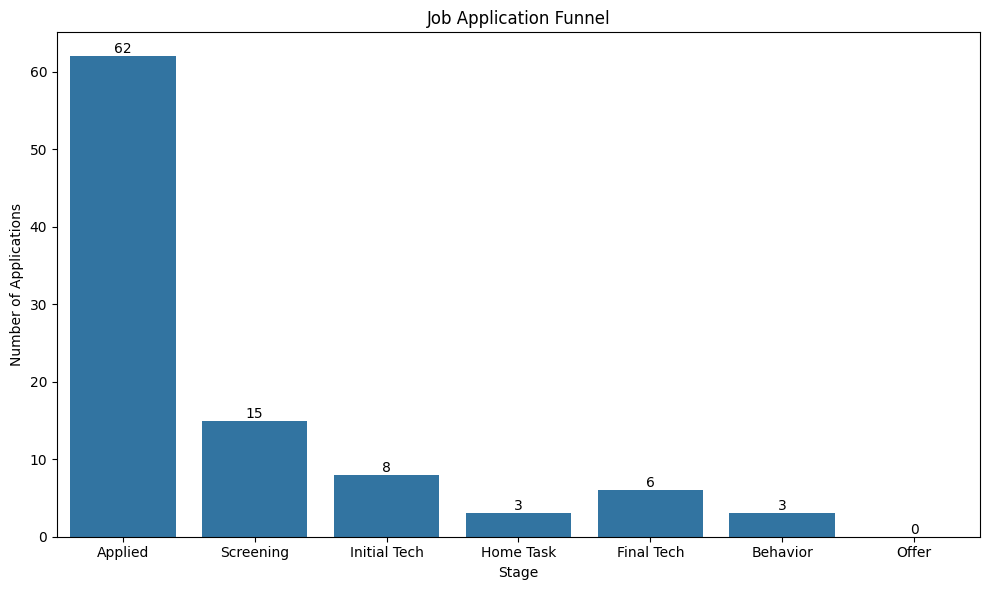

In [179]:
# Funnel Data Preparation.
total_apps = len(df)
funnel = {
    "Applied": total_apps,
    "Screening": df["screening_status"].notnull().sum(),
    "Initial Tech": df["initial_technical_status"].notnull().sum(),
    "Home Task": df[df["home_work_status"] == "YES"].shape[0],
    "Final Tech": df["final_technical_status"].notnull().sum(),
    "Behavior": df["behavior_status"].notnull().sum(),
    "Offer": df["offer_status"].notnull().sum(),
}

# Visualization: Job Application Funnel.
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=list(funnel.keys()), y=list(funnel.values()))
ax.bar_label(ax.containers[0])
plt.title("Job Application Funnel")
plt.xlabel("Stage")
plt.ylabel("Number of Applications")
plt.tight_layout()
plt.savefig(f'media/application_funnel_{datetime.now().strftime("%Y%m%d_%H%M%S")}.png')

### 2. Application Status

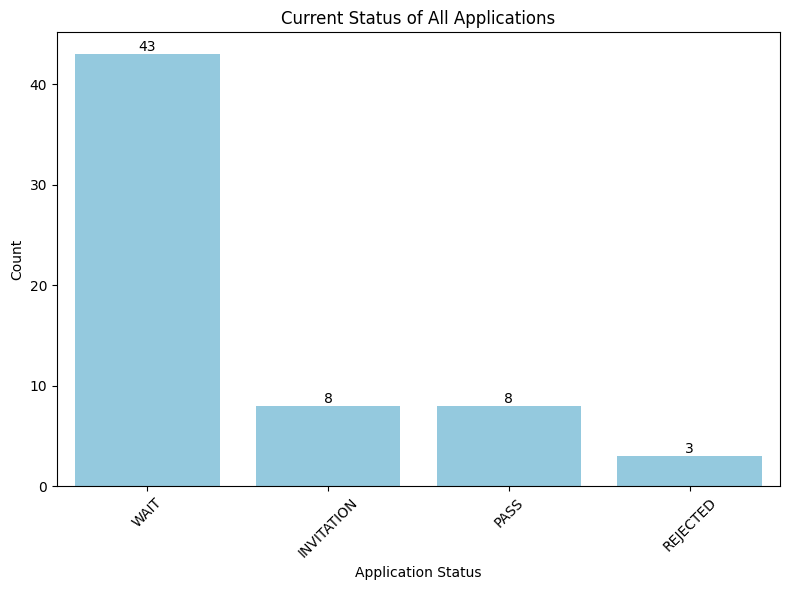

In [180]:
# Status of the applications.
status = df["apply_status"].fillna("UNKNOWN").value_counts()

# Visualization: Application Status Distribution.
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=status.index, y=status.values, color="skyblue")
ax.bar_label(ax.containers[0])
plt.title("Current Status of All Applications")
plt.xlabel("Application Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'media/apply_status_dist_{datetime.now().strftime("%Y%m%d_%H%M%S")}.png')

### 3. Job Titles

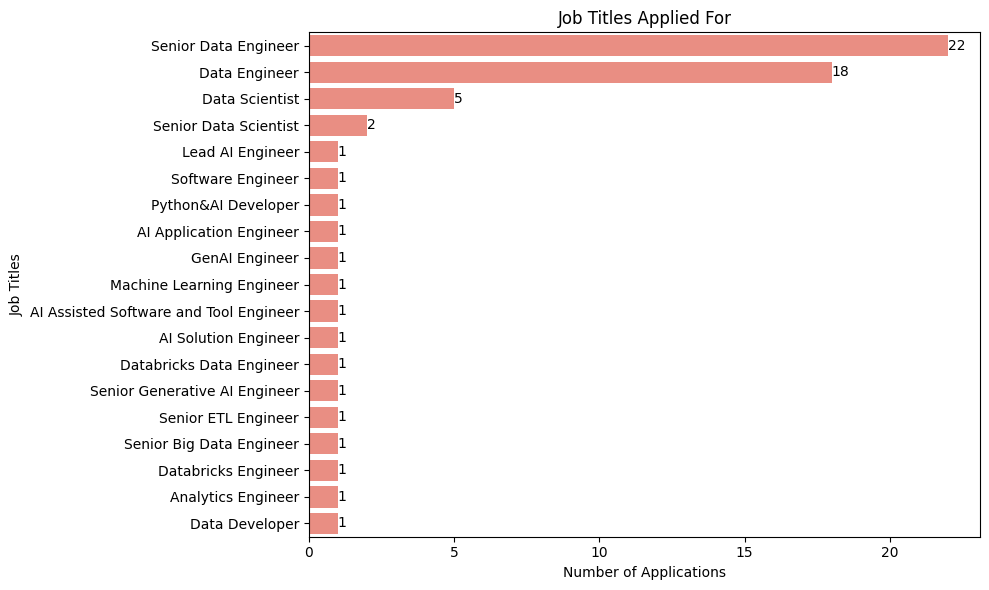

In [181]:
# Title distribution analysis.
titles = df["title"].value_counts().head(20)

# Visualization: Job Titles.
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=titles.values, y=titles.index, color="salmon")
ax.bar_label(ax.containers[0])
plt.title("Job Titles Applied For")
plt.xlabel("Number of Applications")
plt.ylabel("Job Titles")
plt.tight_layout()
plt.savefig(f"media/top_titles_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png")

### 4. Cumulative Application

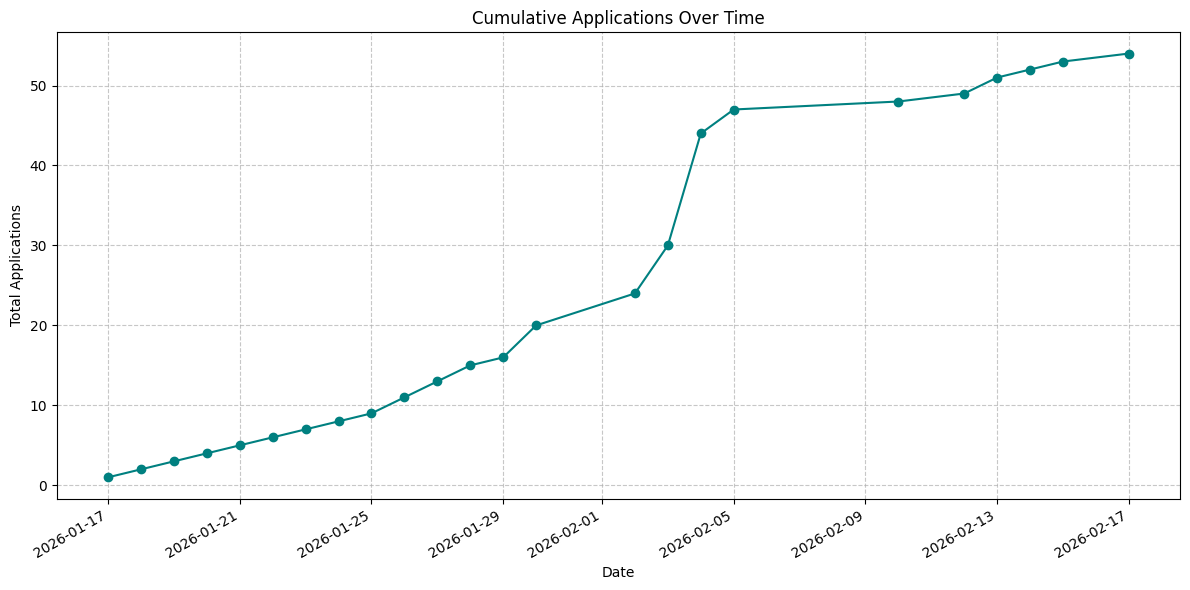

In [182]:
# Visualization: Cumulative Applications Over Time
df_time = df.dropna(subset=["apply_done"]).copy()
if not df_time.empty:
    plt.figure(figsize=(12, 6))
    df_time["apply_done"].value_counts().sort_index().cumsum().plot(
        marker="o", color="teal"
    )
    plt.title("Cumulative Applications Over Time")
    plt.xlabel("Date")
    plt.ylabel("Total Applications")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"media/apps_over_time_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png")

### 5. Conversion Rates

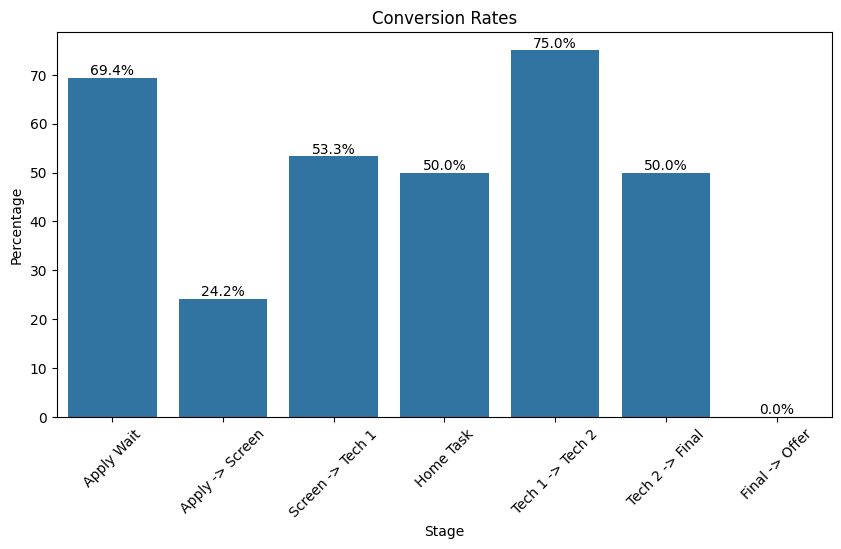

In [183]:
# Calculate Conversion Rates
apply_waiting = (
    ((df["apply_status"] == "WAIT").sum() / len(df) * 100) if len(df) > 0 else 0
)
apply_to_screen = (
    (funnel["Screening"] / funnel["Applied"] * 100) if funnel["Applied"] > 0 else 0
)
screen_to_tech = (
    (funnel["Initial Tech"] / funnel["Screening"] * 100)
    if funnel["Screening"] > 0
    else 0
)
home_task = (
    (
        (df["home_work_status"] == "YES").sum()
        / (df["home_work_status"].notna().sum())
        * 100
    )
    if len(df) > 0
    else 0
)
tech_to_final = (
    (funnel["Final Tech"] / funnel["Initial Tech"] * 100)
    if funnel["Initial Tech"] > 0
    else 0
)
final_to_behavior = (
    (funnel["Behavior"] / funnel["Final Tech"] * 100) if funnel["Final Tech"] > 0 else 0
)
final_to_offer = (
    (funnel["Offer"] / funnel["Final Tech"] * 100) if funnel["Final Tech"] > 0 else 0
)

# Visualization: Conversion Rates.
plt.figure(figsize=(10, 5))
labels = [
    "Apply Wait",
    "Apply -> Screen",
    "Screen -> Tech 1",
    "Home Task",
    "Tech 1 -> Tech 2",
    "Tech 2 -> Final",
    "Final -> Offer",
]
ax = sns.barplot(
    x=labels,
    y=[
        apply_waiting,
        apply_to_screen,
        screen_to_tech,
        home_task,
        tech_to_final,
        final_to_behavior,
        final_to_offer,
    ],
)
ax.bar_label(ax.containers[0], fmt="%.1f%%")
plt.title("Conversion Rates")
plt.xlabel("Stage")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.savefig(f"media/conversion_rates_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png")

### 6. Cycle Time

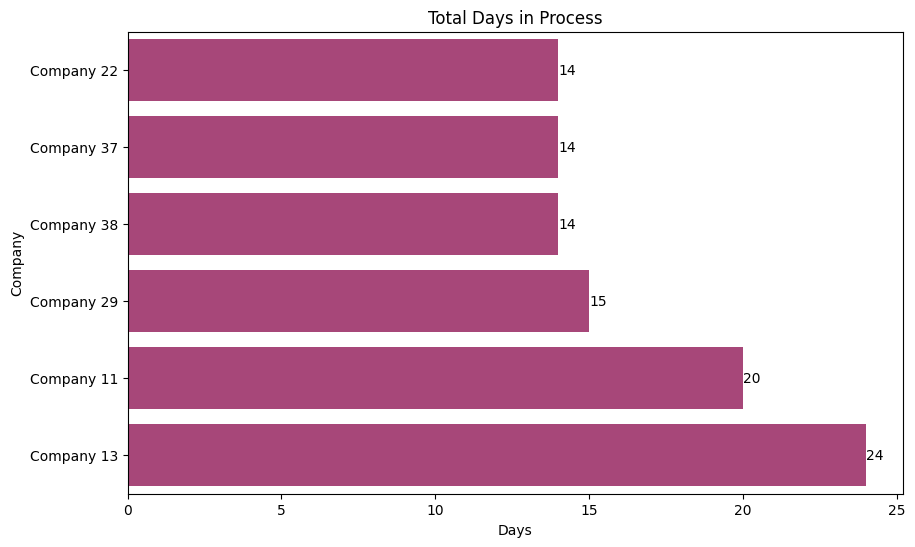

In [184]:
# Total cycle time (Application to last recorded stage).
df["total_cycle_days"] = (
    df[
        [
            "screening_response",
            "initial_technical_response",
            "final_technical_response",
            "behavior_response",
            "offer_response",
        ]
    ].max(axis=1)
    - df["apply_done"]
).dt.days

# Visualization: Total Cycle Time by Company.
fast_track = df.dropna(subset=["total_cycle_days"]).sort_values("total_cycle_days")
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=fast_track,
    x="total_cycle_days",
    y="company",
    palette="magma",
    legend=False,
    hue=1,
)
ax.bar_label(ax.containers[0])
plt.title("Total Days in Process")
plt.xlabel("Days")
plt.ylabel("Company")
plt.savefig(f"media/total_cycle_time_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png")

### 7. Stage Duration

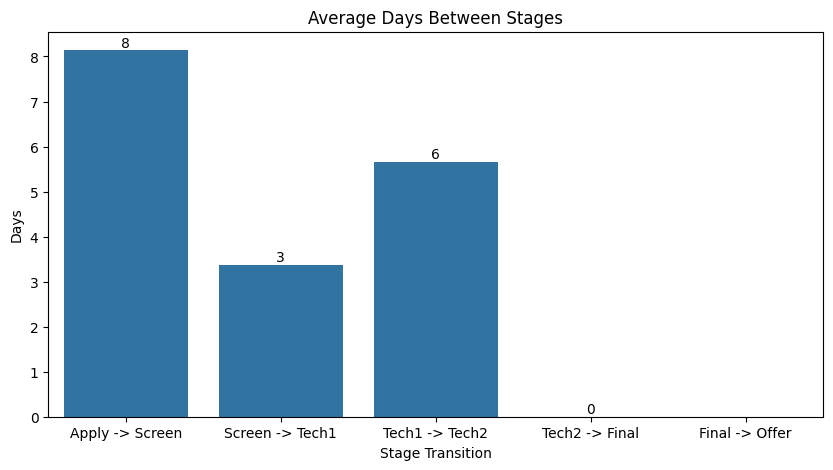

In [185]:
# Calculate Durations.
df["days_apply_to_screen"] = (df["screening_done"] - df["apply_done"]).dt.days
df["days_screen_to_tech1"] = (
    df["initial_technical_done"] - df["screening_done"]
).dt.days
df["days_tech1_to_tech2"] = (
    df["final_technical_done"] - df["initial_technical_done"]
).dt.days
df["days_tech2_to_final"] = (
    df["final_technical_done"] - df["final_technical_done"]
).dt.days
df["days_final_to_offer"] = (df["offer_done"] - df["final_technical_done"]).dt.days

# Visualization: Average Days Between Stages.
plt.figure(figsize=(10, 5))
durations = [
    df["days_apply_to_screen"].mean(),
    df["days_screen_to_tech1"].mean(),
    df["days_tech1_to_tech2"].mean(),
    df["days_tech2_to_final"].mean(),
    df["days_final_to_offer"].mean(),
]
labels = [
    "Apply -> Screen",
    "Screen -> Tech1",
    "Tech1 -> Tech2",
    "Tech2 -> Final",
    "Final -> Offer",
]
ax = sns.barplot(x=labels, y=durations)
ax.bar_label(ax.containers[0], fmt="%.0f")
plt.title("Average Days Between Stages")
plt.xlabel("Stage Transition")
plt.ylabel("Days")
plt.savefig(
    f"media/avg_days_between_stages_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
)